In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error


from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import PrecisionRecallDisplay

In [14]:
df = pd.read_csv(r'C:\Users\Егор\Desktop\fewfer\UDGU_project-master\clearing_df.csv')

In [15]:
y = df['З/П']
X = df.drop(['З/П'], axis = 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [35]:
classifier = RandomForestClassifier(n_estimators= 150, random_state=42, max_depth= 2)
model = classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)
y_proba = classifier.predict_proba(X_test)[:, 1]

Accuracy:0.692
Precision:0.667
Recall:  1.000
F1-score: 0.800

Confusion Matrix:
 [[1 4]
 [0 8]]

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      0.20      0.33         5
         1.0       0.67      1.00      0.80         8

    accuracy                           0.69        13
   macro avg       0.83      0.60      0.57        13
weighted avg       0.79      0.69      0.62        13

F1-результаты по фолдам: [1. 1. 1. 1. 1.]
Средний F1: 1.00


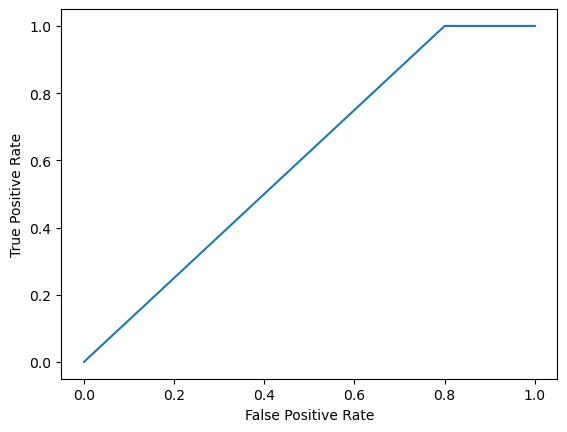

In [36]:
def metrix(prediction,clf, X_test):
    from sklearn.model_selection import cross_val_score
    accuracy_score(prediction, y_test)
    print(f"Accuracy:{accuracy_score(y_test, prediction):.3f}")
    print(f"Precision:{precision_score(y_test, prediction):.3f}")
    print(f"Recall:  {recall_score(y_test, prediction):.3f}")
    print(f"F1-score: {f1_score(y_test, prediction):.3f}")
    # print(f"ROC-AUC:{roc_auc_score(y_test, y_proba):.3f}")
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, prediction))
    print("\nClassification Report:\n", classification_report(y_test, prediction))


    scores_f1 = cross_val_score(clf, X_test, y_test, cv=5, scoring='f1')

    print(f"F1-результаты по фолдам: {scores_f1}")
    print(f"Средний F1: {scores_f1.mean():.2f}")
    from sklearn import metrics
    fpr, tpr, _ = metrics.roc_curve(y_test,  prediction)

    # построение ROC кривой
    plt.plot(fpr, tpr)
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')
    plt.show()
    return
metrix(y_pred, model, X_test)

In [18]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 69.23%


In [19]:
print(f"Accuracy:{accuracy_score(y_test, y_pred):.3f}")
print(f"Precision:{precision_score(y_test, y_pred):.3f}")
print(f"Recall:  {recall_score(y_test, y_pred):.3f}")
print(f"F1-score: {f1_score(y_test, y_pred):.3f}")
print(f"ROC-AUC:{roc_auc_score(y_test, y_proba):.3f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy:0.692
Precision:0.667
Recall:  1.000
F1-score: 0.800
ROC-AUC:0.900

Confusion Matrix:
 [[1 4]
 [0 8]]

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      0.20      0.33         5
         1.0       0.67      1.00      0.80         8

    accuracy                           0.69        13
   macro avg       0.83      0.60      0.57        13
weighted avg       0.79      0.69      0.62        13



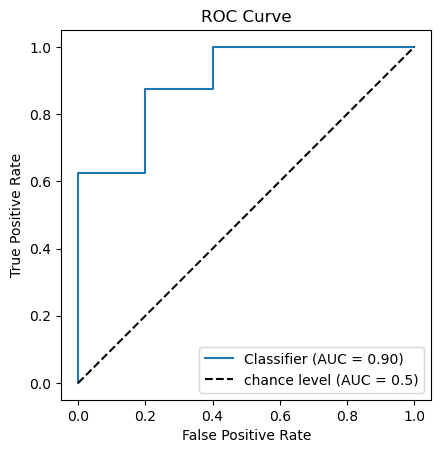

In [20]:
RocCurveDisplay.from_predictions(y_test, y_proba)

plt.plot([0, 1], [0, 1], "k--", label="chance level (AUC = 0.5)") 
plt.axis("square")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

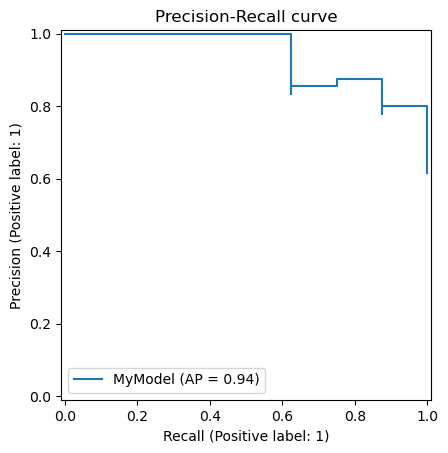

In [21]:
display = PrecisionRecallDisplay.from_predictions(y_test, y_proba, name="MyModel")

_ = display.ax_.set_title("Precision-Recall curve")
plt.show()

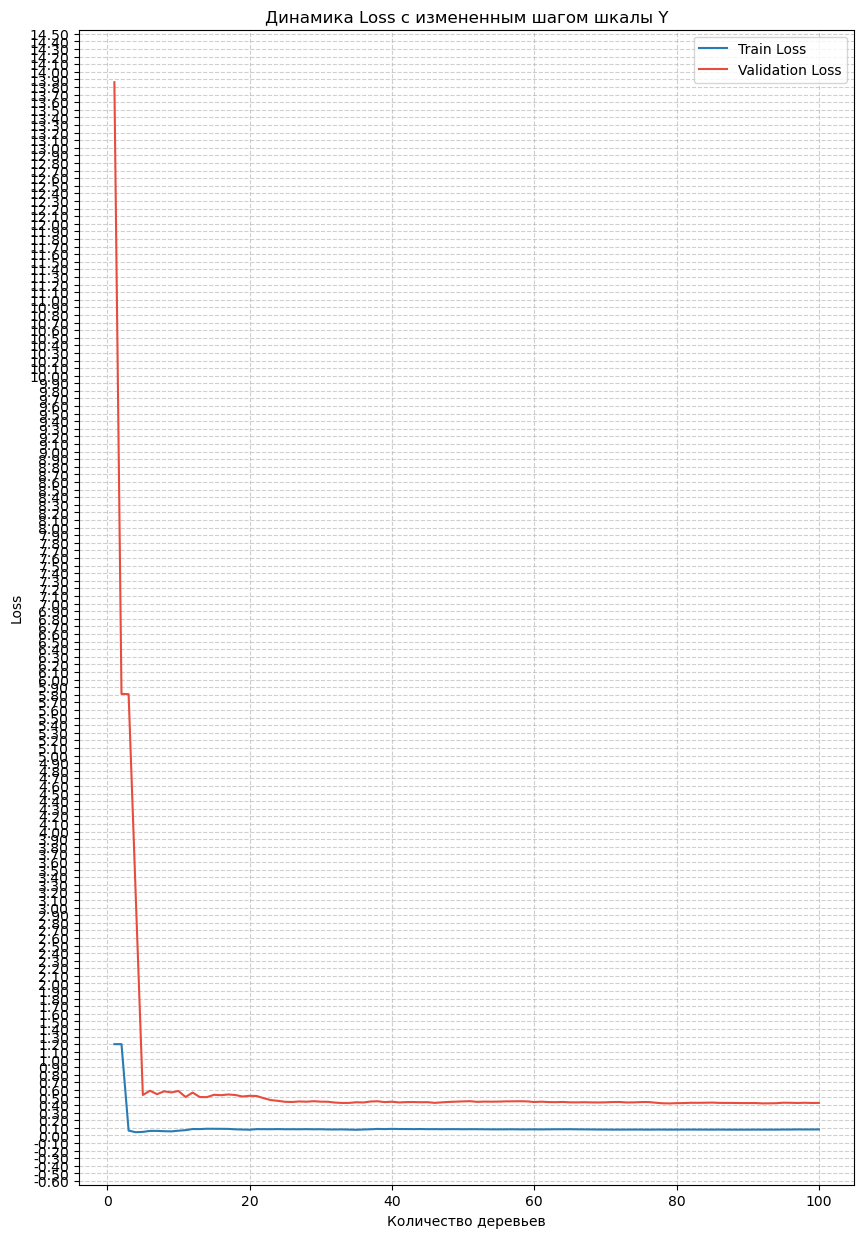

In [22]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import log_loss
import matplotlib.ticker as ticker

train_losses = []
val_losses = []
tree_counts = range(1, 101) # Пройдем от 1 до 100 деревьев

for i in tree_counts:
    model.set_params(n_estimators=i)
    model.fit(X_train, y_train)
    
    # Предсказываем вероятности для расчета Logloss
    train_proba = model.predict_proba(X_train)
    val_proba = model.predict_proba(X_test)
    
    train_losses.append(log_loss(y_train, train_proba))
    val_losses.append(log_loss(y_test, val_proba))

# 2. Визуализация
plt.figure(figsize=(10, 15))
plt.plot(tree_counts, train_losses, label='Train Loss', color="#287bb3")
plt.plot(tree_counts, val_losses, label='Validation Loss', color='#e74c3c')

# НАСТРОЙКА ШКАЛЫ Y
ax = plt.gca() # получаем текущие оси

# Установите желаемый шаг, например 0.05 или 0.1
y_step = 0.1
ax.yaxis.set_major_locator(ticker.MultipleLocator(y_step))

# Можно также настроить формат чисел (например, 2 знака после запятой)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

plt.title('Динамика Loss с измененным шагом шкалы Y')
plt.xlabel('Количество деревьев')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle = '--', alpha=0.6)
plt.show()